In [1]:
# import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv

# Data cleaning

In [3]:
# Reading data
data=pd.read_csv('data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Log_Time        1048575 non-null  object 
 1   Log_Date        1048575 non-null  object 
 2   AL              1048575 non-null  int64  
 3   FROM            1048359 non-null  float64
 4   TO              1048384 non-null  float64
 5   Departure_Time  1048557 non-null  float64
 6   Departure_Date  1048575 non-null  object 
 7   Price           1048545 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 64.0+ MB


In [4]:
#Total null values in each column
data.isnull().sum()

Log_Time            0
Log_Date            0
AL                  0
FROM              216
TO                191
Departure_Time     18
Departure_Date      0
Price              30
dtype: int64

In [5]:
# Removing null values
data=data.dropna()

#Total null values in each column after remobinf nulls
data.isnull().sum()

Log_Time          0
Log_Date          0
AL                0
FROM              0
TO                0
Departure_Time    0
Departure_Date    0
Price             0
dtype: int64

In [6]:
# 455 rows removed because of null values
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1048120 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Log_Time        1048120 non-null  object 
 1   Log_Date        1048120 non-null  object 
 2   AL              1048120 non-null  int64  
 3   FROM            1048120 non-null  float64
 4   TO              1048120 non-null  float64
 5   Departure_Time  1048120 non-null  float64
 6   Departure_Date  1048120 non-null  object 
 7   Price           1048120 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 72.0+ MB


In [7]:
# Describe data to find min, max, and so on
data.describe()

,AL,FROM,TO,Departure_Time,Price
count,1.048120e+06,1.048120e+06,1.048120e+06,1.048120e+06,1.048120e+06
mean,9.724437e+00,5.260648e+01,5.244147e+01,1.438656e+03,8.146197e+01
std,6.056675e+00,2.286707e+01,2.279480e+01,5.452168e+02,3.055645e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,3.000000e+00,4.200000e+01,4.200000e+01,9.400000e+02,6.142680e+01
50%,9.000000e+00,6.600000e+01,6.600000e+01,1.500000e+03,7.674960e+01
75%,1.400000e+01,7.000000e+01,7.000000e+01,1.915000e+03,9.586920e+01
max,2.000000e+01,7.600000e+01,7.600000e+01,2.359000e+03,9.040000e+02


In [8]:
# Number of zeros in the Price
zero_price = data[data['Price'] == 0].shape[0]

print(f"تعداد سطرهای با Price=0: {zero_price}")


تعداد سطرهای با Price=0: 22


In [9]:
#  Delete rows that have zero price 
data = data[(data['Price'] != 0)]


In [11]:
# 22 rows removed because of 0 values in Price 

In [12]:
data.describe()

,AL,FROM,TO,Departure_Time,Price
count,1.048098e+06,1.048098e+06,1.048098e+06,1.048098e+06,1.048098e+06
mean,9.724410e+00,5.260668e+01,5.244150e+01,1.438670e+03,8.146368e+01
std,6.056700e+00,2.286696e+01,2.279481e+01,5.452004e+02,3.055449e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,4.520000e-03
25%,3.000000e+00,4.200000e+01,4.200000e+01,9.400000e+02,6.147200e+01
50%,9.000000e+00,6.600000e+01,6.600000e+01,1.500000e+03,7.674960e+01
75%,1.400000e+01,7.000000e+01,7.000000e+01,1.915000e+03,9.586920e+01
max,2.000000e+01,7.600000e+01,7.600000e+01,2.359000e+03,9.040000e+02


In [30]:
print ('کمترین قیمت:',data['Price'].min())
print ('بیشترین قیمت:',data['Price'].max())

کمترین قیمت: 0.00452
بیشترین قیمت: 650.5184


In [27]:
# Checking for Outliers in price data
# محاسبه Q1 (چارک اول)، Q3 (چارک سوم) و IQR

Q1 = data['Price'].quantile(0.25)
Q3 = data['Price'].quantile(0.75)
IQR = Q3 - Q1

# تعیین کران بالا و پایین
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# پیدا کردن outlierها
outliers = data[(data['Price'] < lower_bound) | (data['Price'] > upper_bound)]
print(f"تعداد outlierها: {len(outliers)}")
print(f"کران پایین: {lower_bound}")
print(f"کران بالا: {upper_bound}")
print("مقادیر outlier:")
print(outliers['Price'].head(10))

تعداد outlierها: 39233
کران پایین: 9.87619999999999
کران بالا: 147.46500000000003
مقادیر outlier:
0      150.2900
40     150.2900
130    190.9700
136    176.1896
177    149.0696
178    160.7764
179    153.5896
203    153.5896
224    155.2620
242    171.3080
Name: Price, dtype: float64


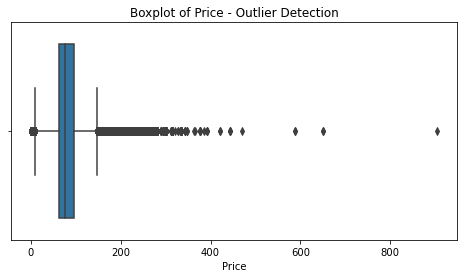

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# رسم boxplot برای Price
plt.figure(figsize=(8, 4))
sns.boxplot(x=data['Price'])
plt.title('Boxplot of Price - Outlier Detection')
plt.show()

In [29]:
# حذف Outlier
data_clean = data[(data['Price'] >= lower_bound) & (data['Price'] <= upper_bound)]

# گزینه 2: جایگزینی با کران بالا/پایین (Capping)
#data_capped = data.copy()
#data_capped['Price'] = data_capped['Price'].clip(lower=lower_bound, upper=upper_bound)

In [31]:
# 39233 rows removed because of outliers values in Price
data_clean.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 1008865 entries, 1 to 1048574
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Log_Time        1008865 non-null  object 
 1   Log_Date        1008865 non-null  object 
 2   AL              1008865 non-null  int64  
 3   FROM            1008865 non-null  float64
 4   TO              1008865 non-null  float64
 5   Departure_Time  1008865 non-null  float64
 6   Departure_Date  1008865 non-null  object 
 7   Price           1008865 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 69.3+ MB


In [35]:
# save to new file
data_clean.to_csv('data_cleaned4050203.csv, index=False, encoding=utf-8-sig')

# Visulaisation

In [4]:
data=pd.read_csv('data_cleaned4050205.csv')

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# تنظیم ظاهر فارسی (اختیاری، برای نمودارها)
plt.rcParams['font.family'] = 'DejaVu Sans'

print(data.head(5))


   Unnamed: 0    Log_Time    Log_Date  AL  FROM  TO FromTo  Route  \
0           1  9:38:33 PM  1395/05/01  18    10  70  10-70  10-70   
1           2  9:38:33 PM  1396/10/08   2     3  70   3-70   3-70   
2           3  9:38:33 PM  1395/04/07  18    75  70  75-70  75-70   
3           4  9:38:33 PM  1395/04/07  18    75  70  75-70  75-70   
4           5  9:38:33 PM  1396/05/23   9    70  49  70-49  70-49   

   Departure_Time Departure_Date    Price  
0            2250     1395/05/05  54.9180  
1            2230     1396/10/09  72.2296  
2            2200     1395/04/11  67.8452  
3            2200     1395/04/11  89.4056  
4            2000     1396/05/26  99.4400  


=== تعداد فروش هر ایرلاین ===
    Airline  Number_of_Sales
0         3           230099
1         9           145713
2         7           104232
3        18            99509
4        20            72332
5        10            66096
6         2            56608
7        14            56292
8        19            54735
9         6            49365
10       12            37285
11       11            16511
12       17            10356
13       16             4962
14        1             4490
15       13              161
16       15              119




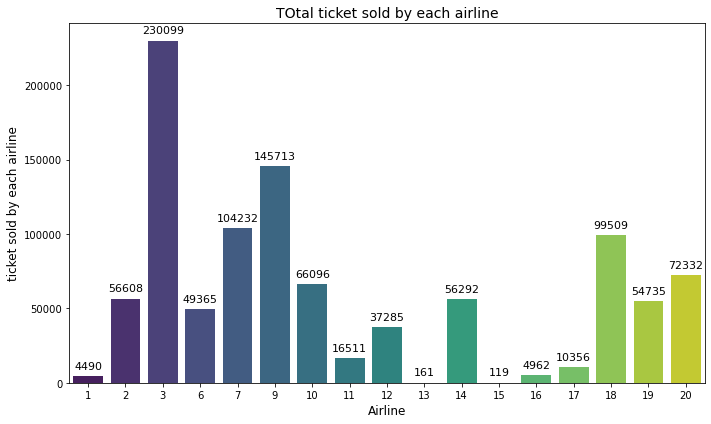

In [7]:
# نمودار 1
# تعداد فروش به ازای هر ایرلاین
demand_by_airline = data['AL'].value_counts().reset_index()
demand_by_airline.columns = ['Airline', 'Number_of_Sales']

print("=== تعداد فروش هر ایرلاین ===")
print(demand_by_airline)
print("\n")

# نمودار
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=demand_by_airline, x='Airline', y='Number_of_Sales', palette='viridis')
# اضافه کردن اعداد روی میله‌ها
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=11, padding=5)
plt.title('TOtal ticket sold by each airline', fontsize=14)
plt.xlabel('Airline', fontsize=12)
plt.ylabel('ticket sold by each airline', fontsize=12)
plt.tight_layout()
plt.show()

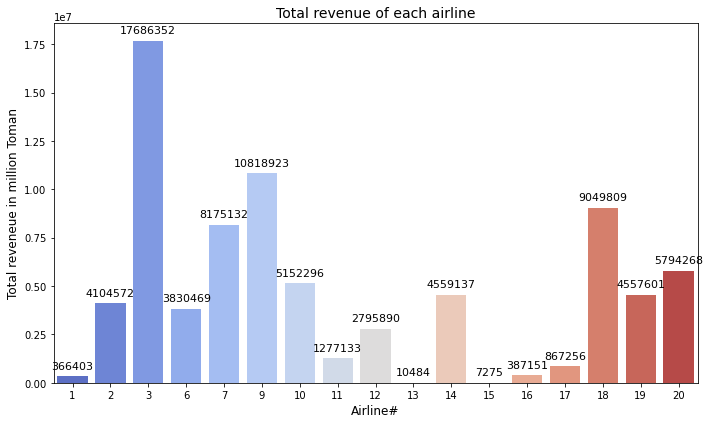

In [8]:
# نمودار 2 جمع فروش هر ایرلاین
# محاسبه داده
revenue_by_airline = data.groupby('AL')['Price'].sum().reset_index()
revenue_by_airline.columns = ['Airline', 'Total_Revenue']
revenue_by_airline = revenue_by_airline.sort_values('Total_Revenue', ascending=False)

# رسم نمودار
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=revenue_by_airline, x='Airline', y='Total_Revenue', palette='coolwarm', ax=ax)

# اضافه کردن اعداد روی میله‌ها (با فرمت هزارگان)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=11, padding=5)

ax.set_title('Total revenue of each airline', fontsize=14)
ax.set_xlabel('Airline#', fontsize=12)
ax.set_ylabel('Total reveneue in million Toman', fontsize=12)

plt.tight_layout()
plt.show()

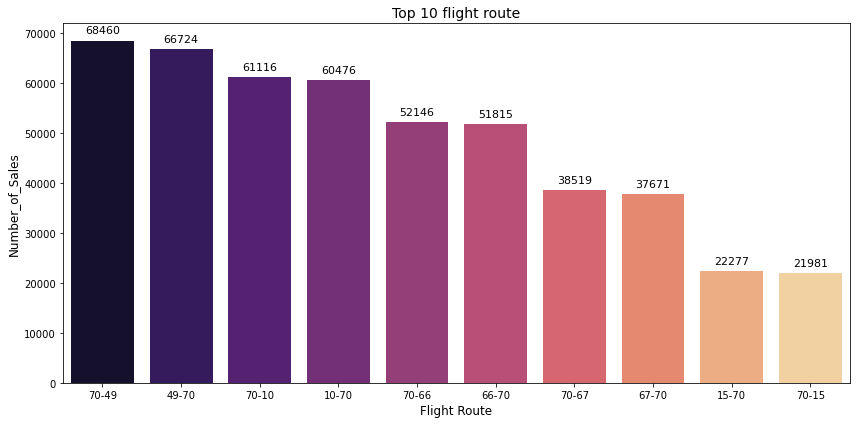

In [17]:
# آماده‌سازی داده


demand_by_route = data['Route'].value_counts().reset_index()
demand_by_route.columns = ['Route', 'Number_of_Sales']
top10_routes = demand_by_route.head(10)

# رسم نمودار
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top10_routes, x='Route', y='Number_of_Sales', palette='magma', ax=ax)

# اضافه کردن اعداد روی میله‌ها
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=11, padding=5)

ax.set_title('Top 10 flight route', fontsize=14)
ax.set_xlabel('Flight Route', fontsize=12)
ax.set_ylabel('Number_of_Sales', fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
demand_by_route.columns = ['Route', 'Number_of_Sales']